In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from lqg import xcorr

from load import load_data, preprocess_data
from constants import sampling_rate


/homes/ds2181/cpp-proprioception/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = load_data(pos=(12, 22))

xy_array = preprocess_data(df, lag=1)


DataFrame loaded from mabel_con_xy_12_22_individualised.csv with shape: (1446247, 11)
Final shape of X array: (40, 182, 2)
Final shape of Y array: (40, 182, 2)
Final shape of XY array: (40, 181, 4)


/homes/ds2181/cpp-proprioception/load.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Trajectory_ID", group_keys=False).apply(subtract_baseline)
/homes/ds2181/cpp-proprioception/load.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda b: downsample_uniform_sample(b, factor=55))


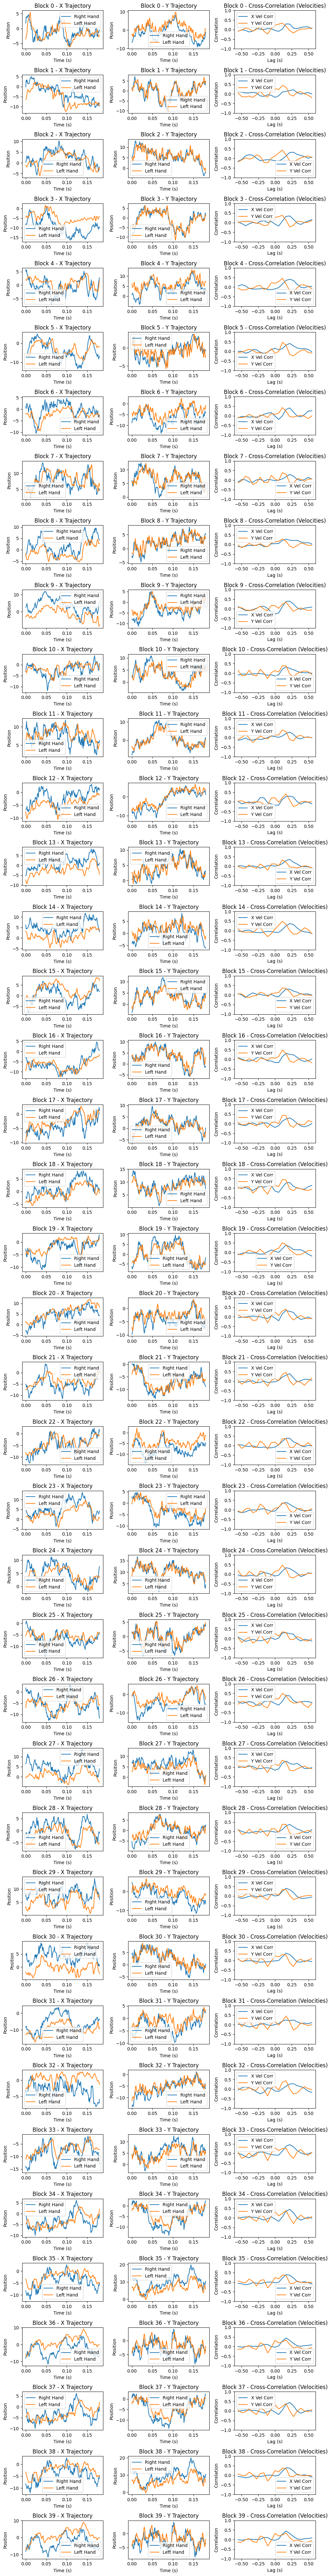

In [3]:

axis_labels = ['X', 'Y']
kinarm_rate = 1000  # Hz
dt = 1 / kinarm_rate
trajectory_ids = range(xy_array.shape[0])
min_count = xy_array.shape[1]
time = np.linspace(0, dt * (min_count - 1), min_count)

# Initialize plots
n_blocks = len(trajectory_ids)
fig, axs = plt.subplots(n_blocks, 3, figsize=(10, 2 * n_blocks), squeeze=False)

for i, block_num in enumerate(trajectory_ids):

    # Plot X and Y hand trajectories
    for j, ax in enumerate(axis_labels):
        right_hand = xy_array[i, :, j * 2]
        left_hand = xy_array[i, :, j * 2 + 1]
        axs[i, j].plot(time, right_hand, label='Right Hand')
        axs[i, j].plot(time, left_hand, label='Left Hand')
        axs[i, j].set_title(f'Block {block_num} - {ax} Trajectory')
        axs[i, j].set_xlabel('Time (s)')
        axs[i, j].set_ylabel('Position')
        axs[i, j].legend()
        # axs[i, j].set_ylim(-10, 10)

    lags_x, corr_x = xcorr(jnp.diff(xy_array[i, :, 1]), jnp.diff(xy_array[i, :, 0]), maxlags=10)
    lags_y, corr_y = xcorr(jnp.diff(xy_array[i, :, 3]), jnp.diff(xy_array[i, :, 2]), maxlags=10)
    axs[i, 2].plot(lags_x/sampling_rate, corr_x, label='X Vel Corr')
    axs[i, 2].plot(lags_y/sampling_rate, corr_y, label='Y Vel Corr')

    axs[i, 2].set_title(f'Block {block_num} - Cross-Correlation (Velocities)')
    axs[i, 2].set_xlabel('Lag (s)')
    axs[i, 2].set_ylabel('Correlation')
    axs[i, 2].legend()
    axs[i, 2].set_ylim(-1, 1)

plt.tight_layout()